In [1]:
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.transforms as transforms
import subprocess
import astropy.units as u
from synphot import SpectralElement, Empirical1D, SourceSpectrum, Observation
import re

import os
gd_folder = os.getcwd()+"/../../Calculations/Gas_and_dust/"

import sys 
sys.path.append(gd_folder)
from polWaveDust import PolWaveDust
from polWaveGas import PolWaveGas

sys.path.append("../utility_functions/")
from objectProperties import ObjectProperties
from readExtrapolatedSpectra import ReadExtrapolatedSpectra

sys.path.append("../../Filter_Curves/")
from readBands import ReadBands

In [2]:
#Use the latex font when plotting. 
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'STIXGeneral'

In [3]:
#Load the properties of the BHDs
op = ObjectProperties()

In [4]:
#Load the bands.
bands = ReadBands()
for bname in bands.bandnames:
    print(bname, bands.bp[bname].barlam(), bands.bp[bname].fwhm(), bands.bp[bname].rectwidth())

R_SPECIAL 6501.229535920617 Angstrom 1159.881393925198 Angstrom 1624.9974574790472 Angstrom
I_BESS 7925.773360798338 Angstrom 1080.5202412457434 Angstrom 1433.1539789444323 Angstrom
v_HIGH 5531.691038305597 Angstrom 850.6231300284223 Angstrom 1195.0838113345558 Angstrom


In [5]:
#Load the spectra for each BHD, extended using the best-fit SED.
specs = ReadExtrapolatedSpectra()

Wavelength range for object W0019-1046 limited because of sky template
Spec-range: 3001.5 Angstrom - 5423.93 Angstrom
Sky-range: 3199.4 Angstrom - 6724.06 Angstrom
Wavelength range for object W0204-0506 limited because of sky template
Spec-range: 3786.2 Angstrom - 6672.70 Angstrom
Sky-range: 3789.3 Angstrom - 6682.76 Angstrom
Warning, 2 of 3161 bins contained negative fluxes; they have been set to zero.
Wavelength range for object W0831+0140 limited because of sky template
Spec-range: 3786.2 Angstrom - 6672.45 Angstrom
Sky-range: 3789.3 Angstrom - 6682.76 Angstrom
Warning, 2 of 3161 bins contained negative fluxes; they have been set to zero.


In [6]:
band_latex_name = {
    "R_SPECIAL": r"$R_{\rm Special}$",
    "I_BESS": r"$I_{\rm Bessel}$",
    "v_HIGH": r"$v_{\rm High}$",
}

In [7]:
def plot_pol(fw, bw):

    #Set output filename prefix. 
    prefix = ""
    if fw:
        prefix += "FW"
    if bw:
        prefix += "BW"
        
    #Set the dust types and the associated labels. 
    dust = ["SMC", "LMC", "MW"]
    dust_labels = ["SMC bar dust", "LMC avg dust", "MW dust"]

    #Set the grid of angles to plot.
    theta_angles = np.arange(0., 90., 2.5)
    psi_angles = np.arange(0., 90., 2.5)

    #Create the Figure. 
    fig, axs = plt.subplots(2,3, figsize=(24,13))

    #Set the properties of the axes.
    for ax in axs.flatten():
        ax.tick_params(axis='both', direction='in', labelsize=25, top=True, right=True, length=10.0)

    ymax = [24., 34.]
    cmap = mpl.cm.jet
    Norm = mpl.colors.Normalize(vmin=theta_angles[0], vmax=theta_angles[-1])

    #Run through the objects/filters we are plotting. 
    for i, wid_band in enumerate([["W0116-0505","I_BESS"], ["W0204-0506","R_SPECIAL"]]):
        wid, band = wid_band
        for k in range(len(dust)):

            #Set the axis properties now more specifically.
            ax = axs[i,k]
            if k>0:
                ax.set_yticklabels([])
            if i<1:
                ax.set_xticklabels([])
            ax.set_ylim([0.01,ymax[i]])
            ax.set_xlim([0,89.])

            #Calculate the broad-band polarization fractions. 
            pw = PolWaveDust(dust[k],fw=fw,bw=bw)
            p_bb = 100*pw.p_bb(bands.bp[band], theta_angles, psi_angles, specs.lam_obs[wid], specs.flam[wid], specs.specs.sp[wid].zspec)

            #Run through every inclination angle plotting the curves.
            for jtheta, theta in enumerate(theta_angles):
                #Set the color
                c = cmap(Norm(theta))
                #Plot
                ax.plot(psi_angles, p_bb[jtheta], color=c, linestyle='solid')

            #Plot the observed polarization fraction.
            ax.plot(ax.get_xlim(), [op.pfrac[wid][band]]*2, ls='dashed', color='xkcd:grey')
            ax.text(np.mean(ax.get_xlim()), op.pfrac[wid][band]+0.5, r"$P_{\rm Observed}$", ha='center',va='bottom', fontsize=22, color='xkcd:grey')

            #Write the labels.
            ax.text(0.95, 0.9, dust_labels[k], ha='right', fontsize=28, transform=ax.transAxes)

            if k==0:
                obj_name = re.sub("-","$-$",wid)
                ax.text(0.05, 0.9, r"{}".format(obj_name), ha='left', fontsize=30, transform=ax.transAxes)
                ax.text(0.05, 0.8, r"{}".format(band_latex_name[band]), ha='left', fontsize=32, transform=ax.transAxes)



    #Draw the colorbar. 
    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.8, 0.11, 0.02, 0.77])
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=Norm, cmap=cmap), cax=cbar_ax)
    cb.set_label(label=r'Inclination Angle $\eta$ (deg)', fontsize=30)
    cb.ax.tick_params(labelsize=20, length=0.) 

    #Set the axes labels.
    fig.subplots_adjust(wspace=0.0,hspace=0.0)
    fig.supxlabel(r"Torus Half-Opening Angle $\psi_{\rm Torus}$ (deg)", y=0.025, fontsize=35)
    fig.supylabel(r"Polarization Fraction $P$ (\%)", x=0.075, fontsize=35)

    #Show and save.
    plt.show()
    fig.savefig("p_psi_small.{}.png".format(prefix), dpi=200, bbox_inches='tight')

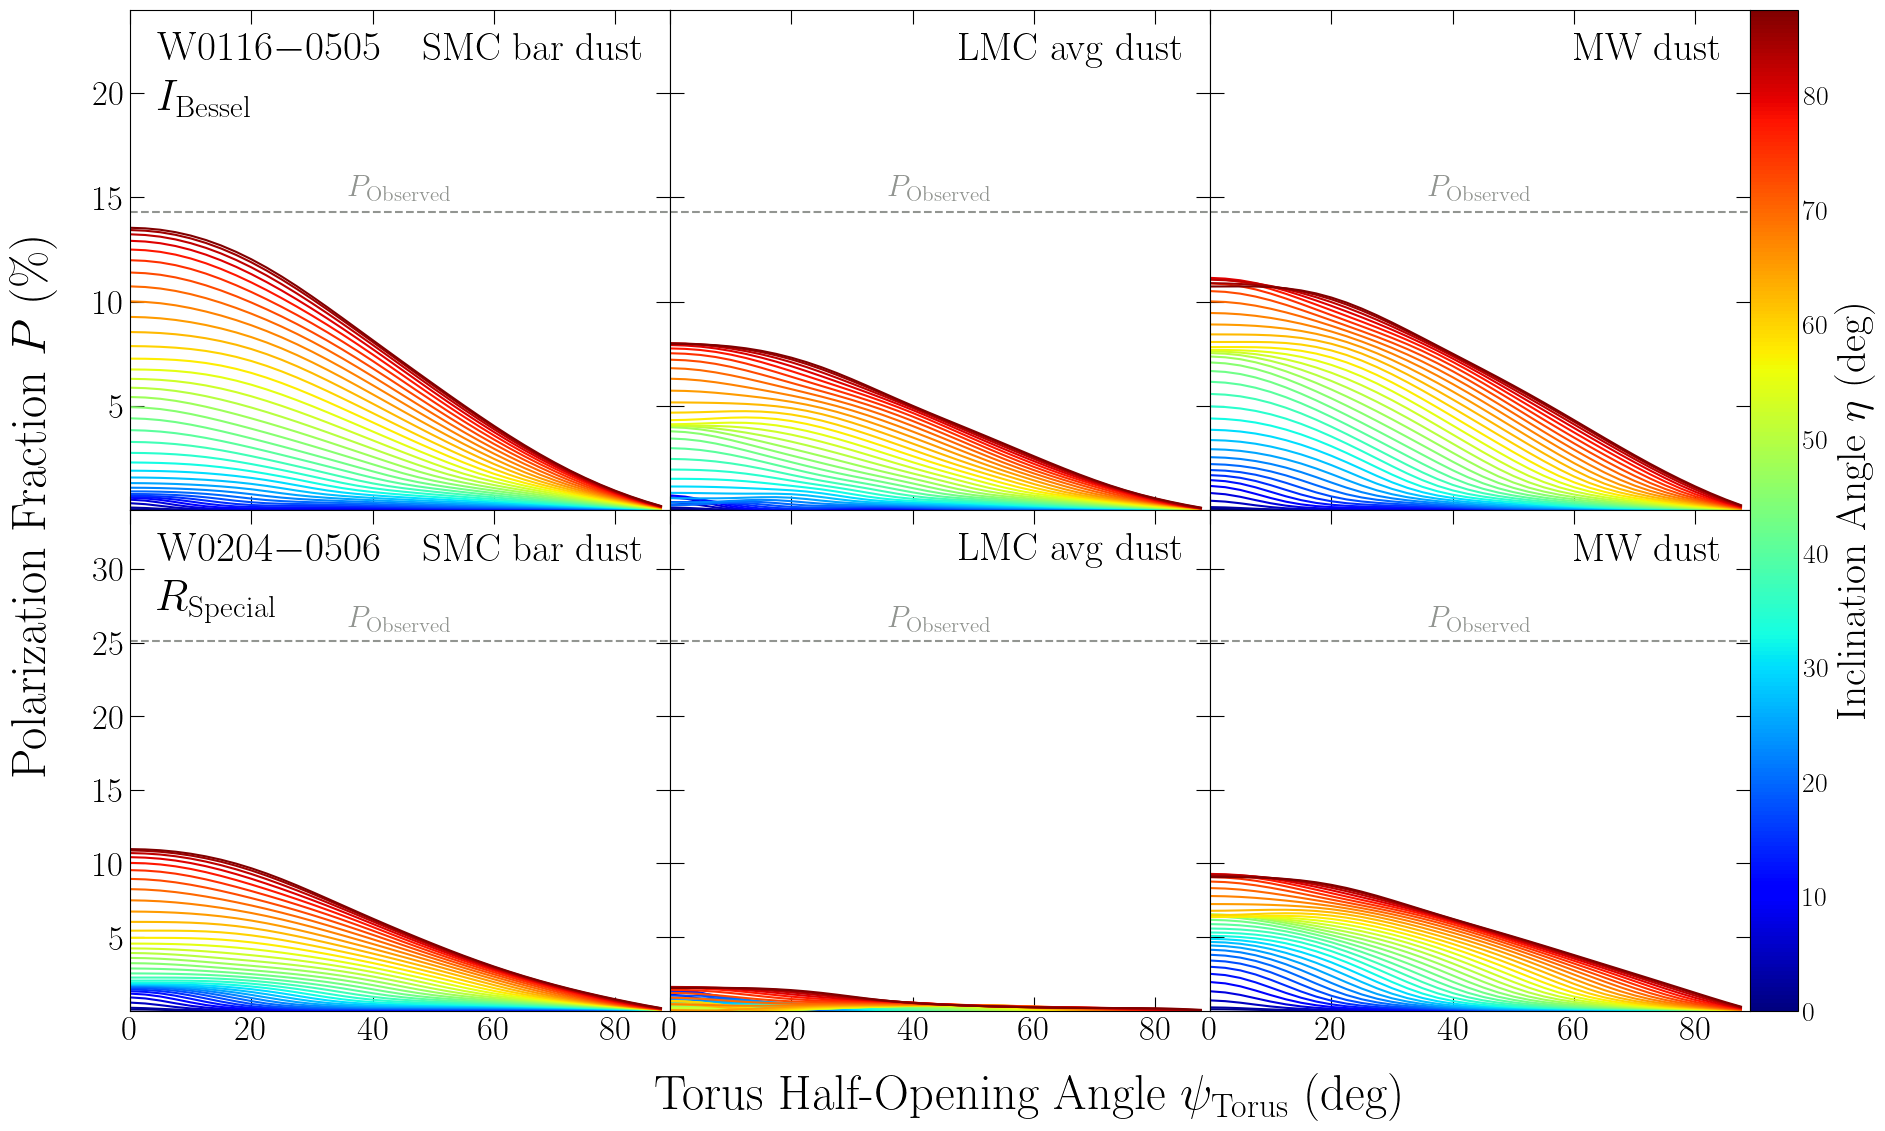

In [8]:
plot_pol(fw=True, bw=True)

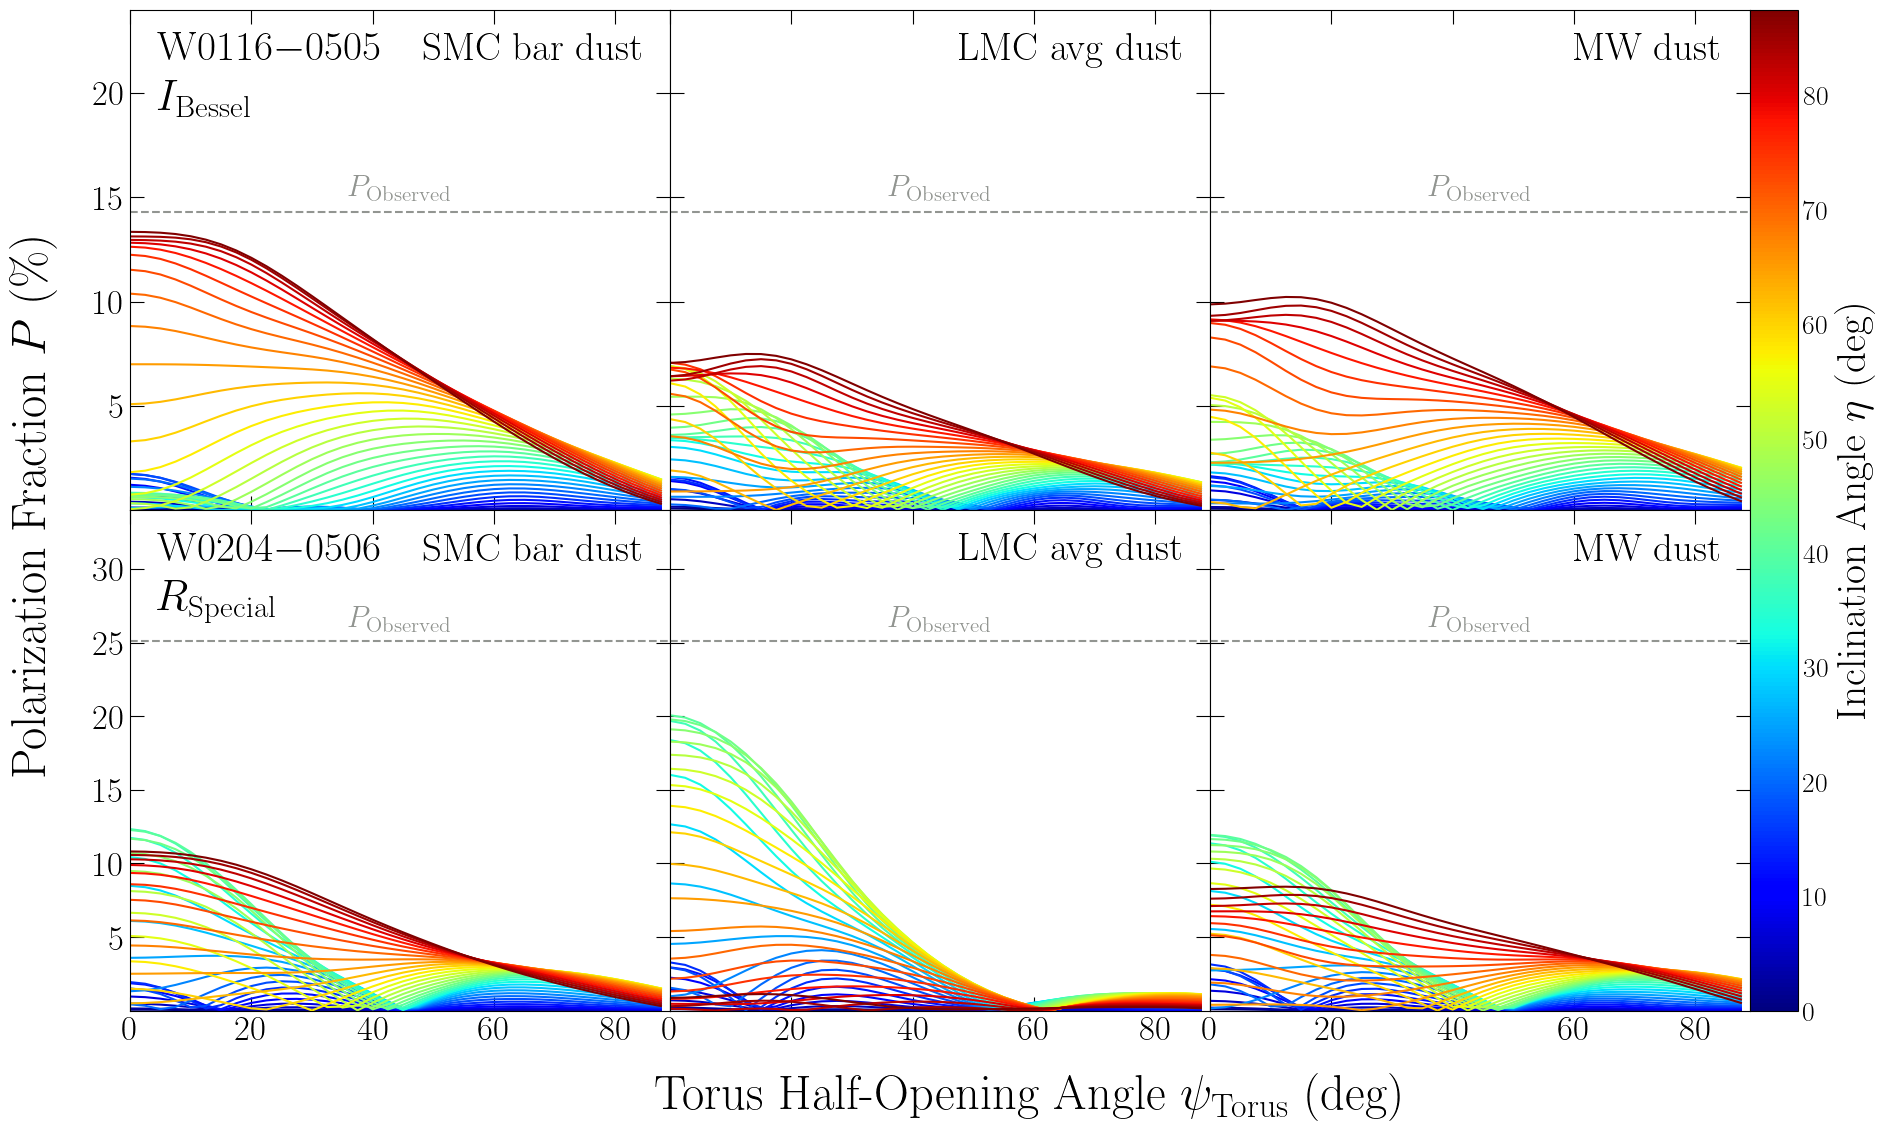

In [9]:
plot_pol(fw=False, bw=True)